# DataCo Inventory Analytics — working notebook

**Business question:** Across this catalog, where is working capital trapped in slow-moving inventory, and how should reorder policies change to free cash without dropping below a 95% service level?

Flow: raw CSV → audit (this section) → DuckDB SQL aggregation → pandas per-SKU stats → 4 layers → `outputs/sku_metrics.csv`.

---
## Audit the raw data

Goal: confirm the data is trustworthy before aggregating. Row count, date range, nulls on the columns every downstream metric depends on, and a first look at demand shape.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "../data/DataCoSupplyChainDataset.csv"

# latin-1: the file has non-UTF-8 bytes and errors under the default encoding
raw = pd.read_csv(RAW, encoding="latin-1")
print(f"rows: {len(raw):,}   columns: {raw.shape[1]}")
raw.head(3)

rows: 180,519   columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [3]:
# The columns every downstream metric depends on.
KEY_COLS = [
    "Product Card Id",              # the SKU key
    "Order Item Quantity",          # demand
    "order date (DateOrders)",      # time axis
    "Product Price",                # value / ABC / EOQ
    "Days for shipping (real)",     # lead time -> safety stock
]

raw[KEY_COLS].info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Product Card Id           180519 non-null  int64  
 1   Order Item Quantity       180519 non-null  int64  
 2   order date (DateOrders)   180519 non-null  str    
 3   Product Price             180519 non-null  float64
 4   Days for shipping (real)  180519 non-null  int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 9.4 MB


In [4]:
# Null check on the key columns
nulls = raw[KEY_COLS].isna().sum()
print("nulls in key columns:")
print(nulls)
assert nulls.sum() == 0, "key columns contain nulls — handle before aggregating"

nulls in key columns:
Product Card Id             0
Order Item Quantity         0
order date (DateOrders)     0
Product Price               0
Days for shipping (real)    0
dtype: int64


In [5]:
# Date range. Source format looks like  M/D/YYYY H:MM  e.g. 1/31/2018 22:56
order_date = pd.to_datetime(raw["order date (DateOrders)"], format="%m/%d/%Y %H:%M")
print("earliest order:", order_date.min())
print("latest order:  ", order_date.max())
print("span (months): ", (order_date.max().to_period("M") - order_date.min().to_period("M")).n + 1)
print("unparsed dates:", order_date.isna().sum())

earliest order: 2015-01-01 00:00:00
latest order:   2018-01-31 23:38:00
span (months):  37
unparsed dates: 0


In [6]:
# Scale of the catalog + basic distributions
print("distinct SKUs (Product Card Id):", raw["Product Card Id"].nunique())
print()
print(raw["Order Item Quantity"].describe())
print()
print(raw["Product Price"].describe())
print()
print("Days for shipping (real):")
print(raw["Days for shipping (real)"].describe())

distinct SKUs (Product Card Id): 118

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64

count    180519.000000
mean        141.232550
std         139.732492
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Product Price, dtype: float64

Days for shipping (real):
count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64


top 10 SKUs by total units:
Product Card Id  Product Name                                 
365              Perfect Fitness Perfect Rip Deck                 73698
502              Nike Men's Dri-FIT Victory Golf Polo             62956
1014             O'Brien Men's Neoprene Life Vest                 57803
191              Nike Men's Free 5.0+ Running Shoe                36680
627              Under Armour Girls' Toddler Spine Surge Runni    31735
403              Nike Men's CJ Elite 2 TD Football Cleat          22246
1004             Field & Stream Sportsman 16 Gun Fire Safe        17325
1073             Pelican Sunstream 100 Kayak                      15500
957              Diamondback Women's Serene Classic Comfort Bi    13729
977              ENO Atlas Hammock Straps                           998
Name: Order Item Quantity, dtype: int64


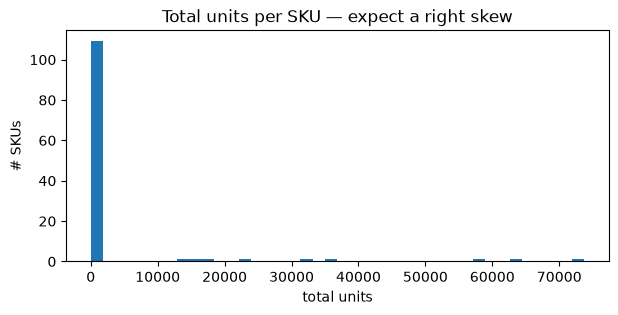

In [7]:
# Do the top sellers make sense, and is total demand right-skewed?
demand_by_sku = (
    raw.groupby(["Product Card Id", "Product Name"])["Order Item Quantity"]
    .sum()
    .sort_values(ascending=False)
)
print("top 10 SKUs by total units:")
print(demand_by_sku.head(10))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(demand_by_sku.values, bins=40)
ax.set_title("Total units per SKU — expect a right skew")
ax.set_xlabel("total units")
ax.set_ylabel("# SKUs")
plt.show()

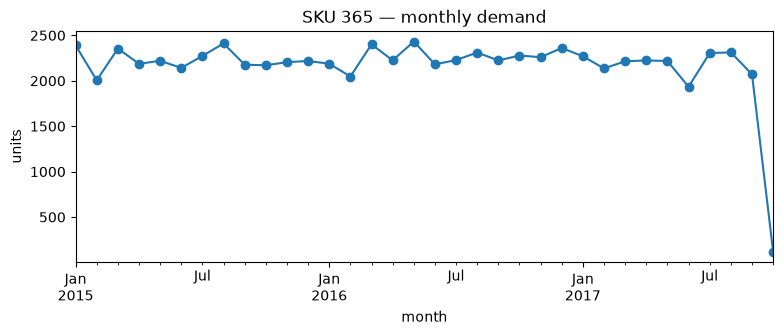

In [8]:
# One SKU's monthly demand series (spot-check the time axis behaves)
top_sku = demand_by_sku.index[0][0]
one = raw.loc[raw["Product Card Id"] == top_sku].copy()
one["month"] = pd.to_datetime(one["order date (DateOrders)"], format="%m/%d/%Y %H:%M").dt.to_period("M")
monthly = one.groupby("month")["Order Item Quantity"].sum()

fig, ax = plt.subplots(figsize=(9, 3))
monthly.plot(ax=ax, marker="o")
ax.set_title(f"SKU {top_sku} — monthly demand")
ax.set_ylabel("units")
plt.show()

### Audit findings (fill in from the output above)

- **Rows / columns:** _..._
- **Date range:** _..._ to _..._  (_N_ months)
- **Distinct SKUs:** _..._
- **Nulls in key columns:** _none / ..._
- **Demand shape:** _right-skewed? a few SKUs carry most volume?_
- **Anything odd:** _negative / zero quantities? zero prices? lead time outliers?_